# Logistic Regression and Naive Bayes - CICIDS2017

**Team member:** Topi Korhonen

**Algorithms:** Logistic Regression, Naive Bayes

## 1. Imports

In [1]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sys.path.append('..')
from data_split import load_and_split_data, RANDOM_STATE

## 2. Load data

In [2]:
CSV_PATH = '../data/cicids2017_cleaned.csv'

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data(
    CSV_PATH, 
    max_rows=100000
)
print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Loading data from ../data/cicids2017_cleaned.csv...
Loaded 100000 rows
Target column: Attack Type
Features: 52 columns
Target distribution:
Attack Type
Normal Traffic    83081
DoS                7673
DDoS               5115
Port Scanning      3574
Brute Force         377
Web Attacks          92
Bots                 88
Name: count, dtype: int64

Train:      60000 rows (60%)
Validation: 20000 rows (20%)
Test:       20000 rows (20%)

X_train: (60000, 52), X_val: (20000, 52), X_test: (20000, 52)


## 3. Feature selection

In [3]:
SELECTED_FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Packet Length Mean",
    "PSH Flag Count",
]

missing = [f for f in SELECTED_FEATURES if f not in X_train.columns]
if missing:
    print(f"WARNING - features not found: {missing}")
else:
    print("All selected features present in dataset.")

X_train_s = X_train[SELECTED_FEATURES]
X_val_s   = X_val[SELECTED_FEATURES]
X_test_s  = X_test[SELECTED_FEATURES]

print(f"Feature set shape: {X_train_s.shape}")

All selected features present in dataset.
Feature set shape: (60000, 10)


## 4. Helper functions

In [4]:

results_log = []
def evaluate_model(name, model, X_tr, y_tr, X_ev, y_ev, label="val"):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    train_acc = accuracy_score(y_tr, model.predict(X_tr))

    y_pred = model.predict(X_ev)
    acc = accuracy_score(y_ev, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_ev, y_pred, average="weighted", zero_division=0
    )

    print(f"\n=== {name} ===")
    print(f"Train accuracy:        {train_acc:.4f}")
    print(f"{label.capitalize()} accuracy:  {acc:.4f}")
    print(f"{label.capitalize()} recall:    {rec:.4f}")
    print(f"{label.capitalize()} F1:        {f1:.4f}")
    print(f"Training time:         {elapsed:.1f}s")
    print(classification_report(y_ev, y_pred, zero_division=0))

    results_log.append({
        "model": name,
        "eval_set": label,
        "train_accuracy": train_acc,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1,
        "train_time_s": elapsed,
    })

    return model, y_pred


def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

---
## LOGISTIC REGRESSION

Logistic Regression is used as a strong baseline linear classifier for multiclass classification. It models class probabilities based on a linear combination of the selected features.

### Logistic Regression - Baseline StandardScaler
Because Logistic Regression is sensitive to feature magnitudes and regularization depends on coefficient scale, StandardScaler is used in the baseline model.

This helps establish a reference point before testing additional preprocessing steps such as SMOTE, PCA, LDA, and hyperparameter tuning.


=== LR - baseline StandardScaler ===
Train accuracy:        0.9428
Val accuracy:  0.9437
Val recall:    0.9437
Val F1:        0.9397
Training time:         1.1s
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        17
   Brute Force       0.00      0.00      0.00        76
          DDoS       0.96      0.64      0.77      1023
           DoS       0.99      0.80      0.88      1534
Normal Traffic       0.95      0.98      0.97     16616
 Port Scanning       0.71      0.98      0.82       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.94     20000
     macro avg       0.52      0.49      0.49     20000
  weighted avg       0.94      0.94      0.94     20000



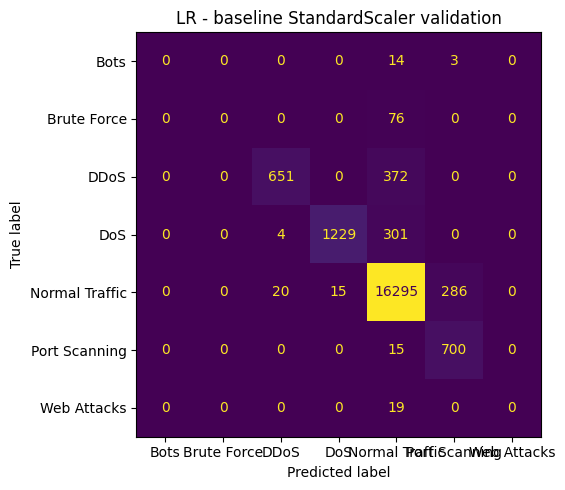

In [5]:
lr_baseline, lr_baseline_pred = evaluate_model(
    "LR - baseline StandardScaler",
    Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            random_state=RANDOM_STATE, max_iter=3000)),
    ]),
    X_train_s, y_train, 
    X_val_s, y_val
)

plot_confusion(y_val, lr_baseline_pred, "LR - baseline StandardScaler validation")

### Logistic Regression - StandardScaler vs MinMaxScaler

Logistic Regression is sensitive to feature scaling because optimisation and regularisation are affected by feature magnitude.

This experiment compares StandardScaler and MinMaxScaler to determine which scaling method provides better validation accuracy and weighted F1-score.

StandardScaler centers features around zero with unit variance, while MinMaxScaler transforms features to a fixed range between 0 and 1.

In [6]:
for scaler_name, scaler in[
    ("StandardScaler", StandardScaler()),
    ("MinMaxScaler", MinMaxScaler()),
]:
    evaluate_model(
        f"LR - {scaler_name}",
        Pipeline([
            ("scaler", scaler),
            ("classifier", LogisticRegression(
                random_state=RANDOM_STATE, max_iter=3000)),
        ]),
        X_train_s, y_train, 
        X_val_s, y_val
    )


=== LR - StandardScaler ===
Train accuracy:        0.9428
Val accuracy:  0.9437
Val recall:    0.9437
Val F1:        0.9397
Training time:         1.0s
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        17
   Brute Force       0.00      0.00      0.00        76
          DDoS       0.96      0.64      0.77      1023
           DoS       0.99      0.80      0.88      1534
Normal Traffic       0.95      0.98      0.97     16616
 Port Scanning       0.71      0.98      0.82       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.94     20000
     macro avg       0.52      0.49      0.49     20000
  weighted avg       0.94      0.94      0.94     20000


=== LR - MinMaxScaler ===
Train accuracy:        0.9263
Val accuracy:  0.9263
Val recall:    0.9263
Val F1:        0.9195
Training time:         0.6s
                precision    recall  f1-score   support

          Bots      

### Logistic Regression - with SMOTE

The dataset is imbalanced because normal traffic samples are much more common than attack samples.

Without balancing, Logistic Regression may favor the majority class and reduce minority-class recall.

SMOTE is tested to generate synthetic minority samples and improve attack detection performance, especially recall and F1-score for minority classes.

The main focus of this comparison is whether SMOTE improves recall without causing a large drop in overall accuracy.


=== LR - StandardScaler + SMOTE ===
Train accuracy:        0.7279
Val accuracy:  0.7299
Val recall:    0.7299
Val F1:        0.7955
Training time:         11.5s
                precision    recall  f1-score   support

          Bots       0.01      1.00      0.02        17
   Brute Force       0.09      0.95      0.16        76
          DDoS       0.44      1.00      0.61      1023
           DoS       0.67      0.84      0.75      1534
Normal Traffic       0.99      0.69      0.81     16616
 Port Scanning       0.71      0.99      0.83       715
   Web Attacks       0.04      0.89      0.08        19

      accuracy                           0.73     20000
     macro avg       0.42      0.91      0.46     20000
  weighted avg       0.92      0.73      0.80     20000



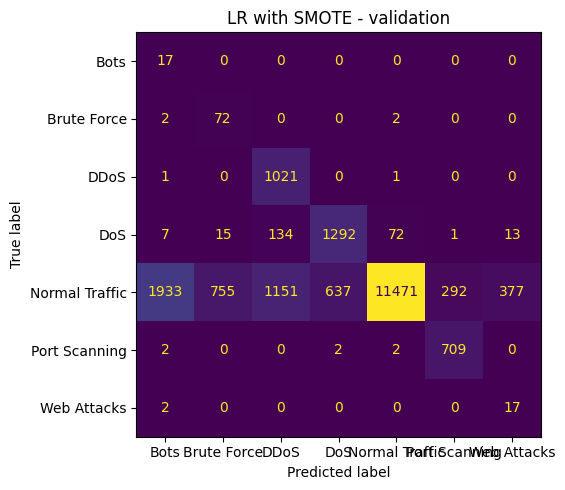

In [7]:
lr_smote, lr_smote_pred = evaluate_model(
    "LR - StandardScaler + SMOTE",
    ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", LogisticRegression(
            random_state=RANDOM_STATE, max_iter=3000)),
    ]),
    X_train_s, y_train, 
    X_val_s, y_val
)

plot_confusion(y_val, lr_smote_pred, "LR with SMOTE - validation")

### Logistic Regression - PCA and LDA

Dimensionality reduction is tested to reduce redundancy between features and improve generalisation.

PCA is an unsupervised method that preserves the largest amount of variance, while LDA is supervised and attempts to max the class seperability.

Because both PCA and LDA are sensitive to feature scale, StandardScaler is applied before dimensionality reduction.

This experiment evaluates whether dimensionality reduction improves Logistic Regression performance or causes information loss.


=== LR - StandardScaler + PCA(0.95) ===
Train accuracy:        0.9393
Val accuracy:  0.9398
Val recall:    0.9398
Val F1:        0.9355
Training time:         1.0s
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        17
   Brute Force       0.00      0.00      0.00        76
          DDoS       0.92      0.62      0.74      1023
           DoS       0.97      0.78      0.86      1534
Normal Traffic       0.95      0.98      0.97     16616
 Port Scanning       0.70      0.98      0.82       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.94     20000
     macro avg       0.51      0.48      0.48     20000
  weighted avg       0.94      0.94      0.94     20000



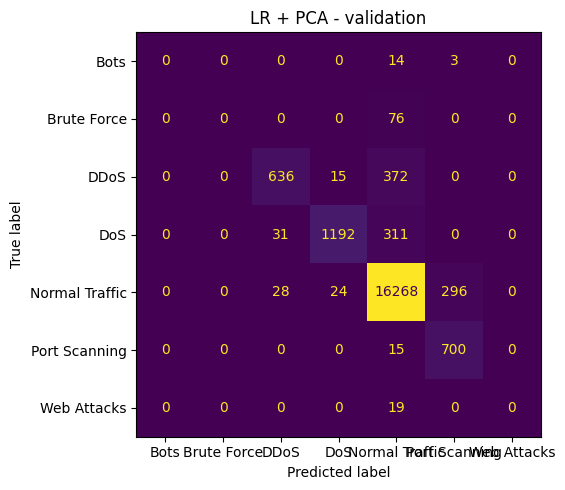

In [8]:
lr_pca, lr_pca_pred = evaluate_model(
    "LR - StandardScaler + PCA(0.95)",
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("classifier", LogisticRegression(
            random_state=RANDOM_STATE, max_iter=3000)),
        ]),
    X_train_s, y_train, 
    X_val_s, y_val
)

plot_confusion(y_val, lr_pca_pred, "LR + PCA - validation")


=== LR - StandardScaler + LDA ===
Train accuracy:        0.9236
Val accuracy:  0.9240
Val recall:    0.9240
Val F1:        0.9182
Training time:         -1.3s
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        17
   Brute Force       0.00      0.00      0.00        76
          DDoS       0.72      0.48      0.58      1023
           DoS       0.84      0.73      0.78      1534
Normal Traffic       0.95      0.97      0.96     16616
 Port Scanning       0.69      0.98      0.81       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.92     20000
     macro avg       0.46      0.45      0.45     20000
  weighted avg       0.92      0.92      0.92     20000



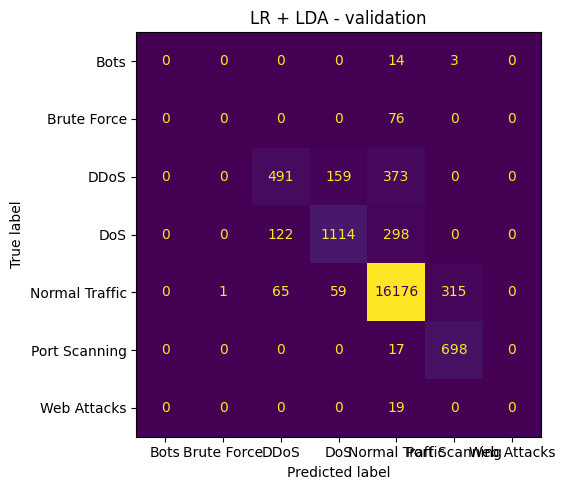

In [9]:
lr_lda, lr_lda_pred = evaluate_model(
    "LR - StandardScaler + LDA",
    Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LDA(n_components=None)),
        ("classifier", LogisticRegression(
            random_state=RANDOM_STATE, max_iter=3000)),
        ]),
    X_train_s, y_train, 
    X_val_s, y_val
)  

plot_confusion(y_val, lr_lda_pred, "LR + LDA - validation")

### Logistic Regression - GridSearchCV

GridSearchCV is used to systematically tune the most important Logistic Regression hyperparameters and preprocessing combinations.

The search includes scaling method, SMOTE usage, dimensionality reduction, regularisation strength (C), and class balancing using class_weight.

The objective is to identify the best overall model based on weighted F1-score using 3-fold cross-validation.

This allows a more reliable model selection than manual testing alone.

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END classifier__C=0.1, classifier__class_weight=None, dimred=PCA(n_components=0.95), scaler=MinMaxScaler(), smote=passthrough; total time=   0.5s
[CV] END classifier__C=0.1, classifier__class_weight=None, dimred=PCA(n_components=0.95), scaler=StandardScaler(), smote=passthrough; total time=   0.9s
[CV] END classifier__C=0.1, classifier__class_weight=None, dimred=PCA(n_components=0.95), scaler=StandardScaler(), smote=passthrough; total time=   0.8s
[CV] END classifier__C=0.1, classifier__class_weight=None, dimred=PCA(n_components=0.95), scaler=MinMaxScaler(), smote=passthrough; total time=   0.6s
[CV] END classifier__C=0.1, classifier__class_weight=None, dimred=LinearDiscriminantAnalysis(), scaler=StandardScaler(), smote=passthrough; total time=   1.2s
[CV] END classifier__C=0.1, classifier__class_weight=None, dimred=PCA(n_components=0.95), scaler=MinMaxScaler(), smote=passthrough; total time=   0.8s
[CV] END classifier_

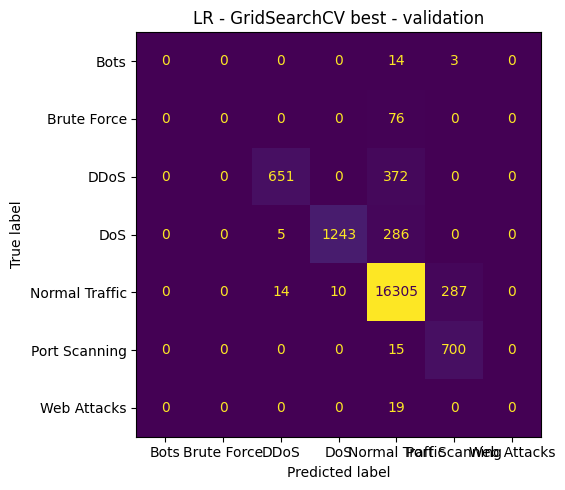

In [10]:
lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("dimred", "passthrough"),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=3000)),
])

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid={
        "scaler": [StandardScaler(), MinMaxScaler()],
        "smote": [SMOTE(random_state=RANDOM_STATE), "passthrough"],
        "dimred": [PCA(n_components=0.95), LDA(), "passthrough"],
        "classifier__C": [0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"],
    },
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2,
)

lr_best, lr_best_pred = evaluate_model(
    "LR - GridSearchCV best",
    lr_grid,
    X_train_s, y_train, 
    X_val_s, y_val
)

print(f"\nBest LR params: {lr_grid.best_params_}")
plot_confusion(y_val, lr_best_pred, "LR - GridSearchCV best - validation")

---



# Naive Bayes

### Naive Bayes - baseline

Gaussian Naive Bayes is used as a fast probabilistic baseline model for multiclass classification.

It assumes that features follow a normal distribution and are conditionally independent within each class.

StandardScaler is used for consistency and numerical stability.


=== NB - baseline StandardScaler ===
Train accuracy:        0.2962
Val accuracy:  0.2969
Val recall:    0.2969
Val F1:        0.3380
Training time:         0.0s
                precision    recall  f1-score   support

          Bots       0.00      0.29      0.00        17
   Brute Force       0.01      0.96      0.02        76
          DDoS       0.60      1.00      0.75      1023
           DoS       0.29      0.89      0.44      1534
Normal Traffic       0.99      0.17      0.28     16616
 Port Scanning       0.71      0.98      0.82       715
   Web Attacks       0.03      0.89      0.06        19

      accuracy                           0.30     20000
     macro avg       0.38      0.74      0.34     20000
  weighted avg       0.90      0.30      0.34     20000



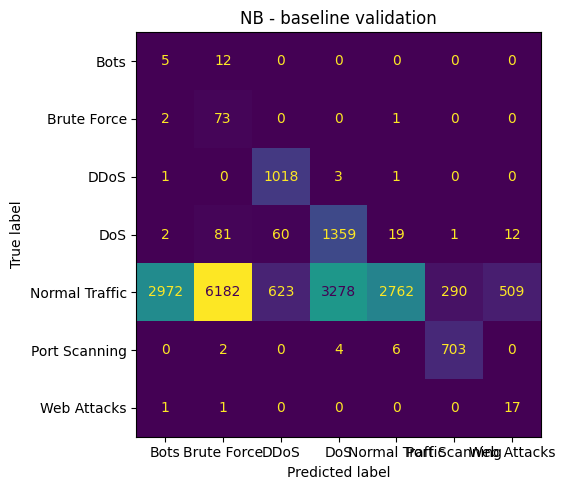

In [11]:
nb_baseline, nb_baseline_pred = evaluate_model(
    "NB - baseline StandardScaler",
    Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", GaussianNB()),
    ]),
    X_train_s, y_train, 
    X_val_s, y_val
)

plot_confusion(y_val, nb_baseline_pred, "NB - baseline validation")

### Naive Bayes - StandardScaler vs MinMaxScaler

Naive Bayes is generally less sensitive to feature scaling than Logistic Regression, but scaling can still affect numerical stability and probability estimation.

This experiment compares StandardScaler and MinMaxScaler to evaluate whether scaling improves validation accuracy and weighted F1-score.

The goal is also to document whether scaling meaningfully affects Naive Bayes performance.

In [12]:
for scaler_name, scaler in[
    ("StandardScaler", StandardScaler()),
    ("MinMaxScaler", MinMaxScaler()),
]:
    evaluate_model(
        f"NB - {scaler_name}",
        Pipeline([
            ("scaler", scaler),
            ("classifier", GaussianNB()),
        ]),
        X_train_s, y_train, 
        X_val_s, y_val
    )


=== NB - StandardScaler ===
Train accuracy:        0.2962
Val accuracy:  0.2969
Val recall:    0.2969
Val F1:        0.3380
Training time:         -2.4s
                precision    recall  f1-score   support

          Bots       0.00      0.29      0.00        17
   Brute Force       0.01      0.96      0.02        76
          DDoS       0.60      1.00      0.75      1023
           DoS       0.29      0.89      0.44      1534
Normal Traffic       0.99      0.17      0.28     16616
 Port Scanning       0.71      0.98      0.82       715
   Web Attacks       0.03      0.89      0.06        19

      accuracy                           0.30     20000
     macro avg       0.38      0.74      0.34     20000
  weighted avg       0.90      0.30      0.34     20000


=== NB - MinMaxScaler ===
Train accuracy:        0.2704
Val accuracy:  0.2711
Val recall:    0.2711
Val F1:        0.2939
Training time:         0.0s
                precision    recall  f1-score   support

          Bots     

### Naive Bayes - with SMOTE

Because the dataset contains class imbalance, SMOTE is tested to improve minority-class recall.

Naive Bayes relies on estimated probability distributions, so synthetic samples may sometimes distort those distributions rather than improve performance.

In this experiment we evaluate whether SMOTE improves attack detection recall or negatively affects probability estimation.


=== NB - StandardScaler + SMOTE ===
Train accuracy:        0.2954
Val accuracy:  0.2942
Val recall:    0.2942
Val F1:        0.3423
Training time:         0.4s
                precision    recall  f1-score   support

          Bots       0.00      0.29      0.00        17
   Brute Force       0.01      0.59      0.02        76
          DDoS       0.68      0.99      0.81      1023
           DoS       0.33      0.89      0.48      1534
Normal Traffic       0.99      0.16      0.28     16616
 Port Scanning       0.71      0.98      0.83       715
   Web Attacks       0.03      0.89      0.05        19

      accuracy                           0.29     20000
     macro avg       0.39      0.69      0.35     20000
  weighted avg       0.91      0.29      0.34     20000



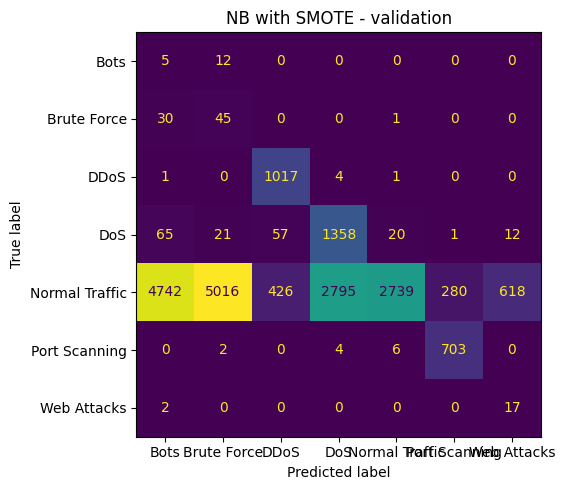

In [13]:
nb_smote, nb_smote_pred = evaluate_model(
    "NB - StandardScaler + SMOTE",
    ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", GaussianNB()),
    ]),
    X_train_s, y_train, 
    X_val_s, y_val
)

plot_confusion(y_val, nb_smote_pred, "NB with SMOTE - validation")

### Naive Bayes - PCA

PCA is tested to reduce feature redundancy and noise before classification.

Unlike Logistic Regression, Naive Bayes does not benefit strongly from feature interactions, so Polynomial Features and LDA are not prioritised.

The goal is to evaluate whether PCA improves generalisation by simplifying the feature space or reduces performance due to information loss.


=== NB - StandardScaler + PCA(0.95) ===
Train accuracy:        0.5212
Val accuracy:  0.5169
Val recall:    0.5169
Val F1:        0.6243
Training time:         0.1s
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        17
   Brute Force       0.01      0.57      0.01        76
          DDoS       0.54      0.47      0.50      1023
           DoS       0.59      0.75      0.66      1534
Normal Traffic       0.93      0.48      0.63     16616
 Port Scanning       0.47      0.97      0.63       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.52     20000
     macro avg       0.36      0.46      0.35     20000
  weighted avg       0.86      0.52      0.62     20000



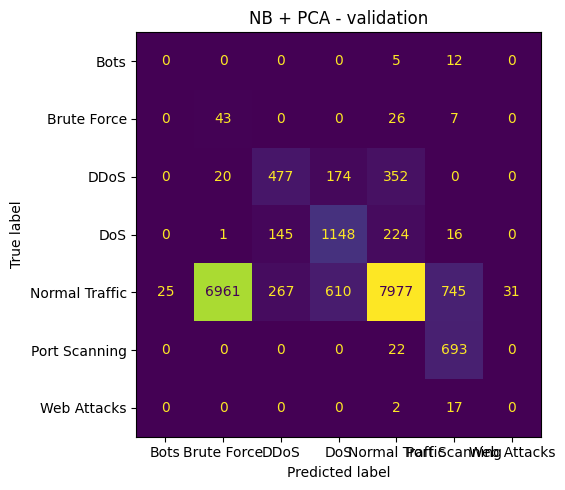

In [14]:
nb_pca, nb_pca_pred = evaluate_model(
    "NB - StandardScaler + PCA(0.95)",
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("classifier", GaussianNB()),
        ]),
    X_train_s, y_train, 
    X_val_s, y_val
)

plot_confusion(y_val, nb_pca_pred, "NB + PCA - validation")

### Naive Bayes - GridSearchCV

GridSearchCV is used to systematically test preprocessing choices and the main Naive Bayes hyperparameter, var_smoothing.

The search includes scaling method, SMOTE usage, PCA, and different var_smoothing values.

The best model is selected using weighted F1-score with 3-fold cross-validation to ensure fair comparison with the other classification algorithms used in the project.

Fitting 3 folds for each of 32 candidates, totalling 96 fits

=== NB - GridSearchCV best ===
Train accuracy:        0.8266
Val accuracy:  0.8273
Val recall:    0.8273
Val F1:        0.8436
Training time:         2.7s
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        17
   Brute Force       0.00      0.00      0.00        76
          DDoS       0.28      0.48      0.36      1023
           DoS       0.69      0.74      0.72      1534
Normal Traffic       0.96      0.85      0.90     16616
 Port Scanning       0.41      0.99      0.58       715
   Web Attacks       0.00      0.00      0.00        19

      accuracy                           0.83     20000
     macro avg       0.33      0.44      0.36     20000
  weighted avg       0.88      0.83      0.84     20000


Best NB params: {'classifier__var_smoothing': 1e-09, 'dimred': PCA(n_components=0.95), 'scaler': MinMaxScaler(), 'smote': 'passthrough'}


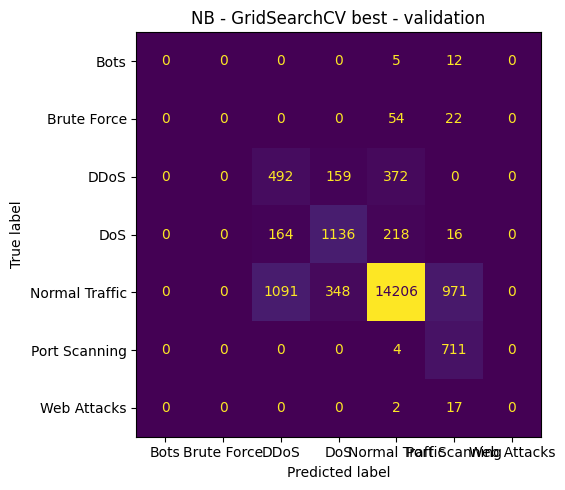

In [15]:
nb_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", "passthrough"),
    ("dimred", "passthrough"),
    ("classifier", GaussianNB()),
])

nb_grid = GridSearchCV(
    nb_pipeline,
    param_grid={
        "scaler": [StandardScaler(), MinMaxScaler()],
        "smote": [SMOTE(random_state=RANDOM_STATE), "passthrough"],
        "dimred": [PCA(n_components=0.95), "passthrough"],
        "classifier__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6],
    },
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

nb_best, nb_best_pred = evaluate_model(
    "NB - GridSearchCV best",
    nb_grid,
    X_train_s, y_train, 
    X_val_s, y_val
)

print(f"\nBest NB params: {nb_grid.best_params_}")
plot_confusion(y_val, nb_best_pred, "NB - GridSearchCV best - validation")